In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"Libraries imported")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Libraries imported
Device: cuda
GPU: NVIDIA GeForce RTX 5090


In [2]:
ratings = pd.read_csv('../data/ml-25m/ratings.csv')
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

split_date = '2015-01-01'
train = ratings[ratings['datetime'] < split_date].copy()
test = ratings[ratings['datetime'] >= split_date].copy()

# Normalize ratings to 0-1 scale
min_rating = 0.5
max_rating = 5.0
train['rating'] = (train['rating'] - min_rating) / (max_rating - min_rating)
test['rating'] = (test['rating'] - min_rating) / (max_rating - min_rating)

print(f"Train: {len(train):,} ratings")
print(f"Test: {len(test):,} ratings")
print(f"Rating range: {train['rating'].min():.2f} - {train['rating'].max():.2f}")


Train: 17,436,354 ratings
Test: 7,563,741 ratings
Rating range: 0.00 - 1.00


In [3]:
user_ids = train['userId'].unique()
movie_ids = train['movieId'].unique()

user_id_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

index_to_user_id = {idx: user_id for user_id, idx in user_id_to_index.items()}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}

train['user_index'] = train['userId'].map(user_id_to_index)
train['movie_index'] = train['movieId'].map(movie_id_to_index)
test['user_index'] = test['userId'].map(user_id_to_index)
test['movie_index'] = test['movieId'].map(movie_id_to_index)

n_users = len(user_ids)
n_movies = len(movie_ids)

print(f"Number of users:  {n_users:,}")
print(f"Number of movies: {n_movies:,}")
print(f"Test cold start users: {test['user_index'].isna().sum():,}")

Number of users:  121,673
Number of movies: 22,316
Test cold start users: 6,836,326


In [4]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for user, movie, rating in loader:
        user = user.to(device)
        movie = movie.to(device)
        rating = rating.to(device)
        
        predictions = model(user, movie)
        loss = criterion(predictions, rating)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_actuals = []
    
    with torch.no_grad():
        for user, movie, rating in loader:
            user = user.to(device)
            movie = movie.to(device)
            rating = rating.to(device)
            
            predictions = model(user, movie)
            loss = criterion(predictions, rating)
            total_loss += loss.item()
            
            all_predictions.extend(predictions.cpu().numpy())
            all_actuals.extend(rating.cpu().numpy())
    
    rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
    mae = mean_absolute_error(all_actuals, all_predictions)
    
    return total_loss / len(loader), rmse, mae

print("Training functions")
print("GPU transfers")

Training functions
GPU transfers


In [5]:
class MovieRatingDataset(Dataset):
    def __init__(self, dataframe):
        valid = dataframe['user_index'].notna() & dataframe['movie_index'].notna()
        dataframe = dataframe[valid].reset_index(drop=True)
        
        # Convert to tensors once upfront - keep on CPU
        self.users = torch.tensor(
            dataframe['user_index'].values, dtype=torch.long)
        self.movies = torch.tensor(
            dataframe['movie_index'].values, dtype=torch.long)
        self.ratings = torch.tensor(
            dataframe['rating'].values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]

# Create datasets
train_dataset = MovieRatingDataset(train)
test_dataset = MovieRatingDataset(test)

# Optimized DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=4096,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4096,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Train dataset: {len(train_dataset):,}")
print(f"Test dataset:  {len(test_dataset):,}")
print(f"Train batches: {len(train_loader):,}")
print(f"Batch size:    4,096")

Train dataset: 17,436,354
Test dataset:  546,990
Train batches: 4,257
Batch size:    4,096


In [6]:
class MovieRatingDataset(Dataset):
    def __init__(self, dataframe):
        valid = dataframe['user_index'].notna() & dataframe['movie_index'].notna()
        dataframe = dataframe[valid].reset_index(drop=True)
        
        # Convert to tensors once upfront - keep on CPU
        self.users = torch.tensor(
            dataframe['user_index'].values, dtype=torch.long)
        self.movies = torch.tensor(
            dataframe['movie_index'].values, dtype=torch.long)
        self.ratings = torch.tensor(
            dataframe['rating'].values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]

# Create datasets
train_dataset = MovieRatingDataset(train)
test_dataset = MovieRatingDataset(test)

# Optimized DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=4096,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4096,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Train dataset: {len(train_dataset):,}")
print(f"Test dataset:  {len(test_dataset):,}")
print(f"Train batches: {len(train_loader):,}")
print(f"Batch size:    4,096")

Train dataset: 17,436,354
Test dataset:  546,990
Train batches: 4,257
Batch size:    4,096


In [7]:
class NeuMF(nn.Module):
    def __init__(self, n_users, n_movies, gmf_dim=32, mlp_dim=64, dropout=0.3):
        super(NeuMF, self).__init__()
        
        # ── GMF path ──────────────────────────────────────────
        self.gmf_user_embedding = nn.Embedding(n_users, gmf_dim)
        self.gmf_movie_embedding = nn.Embedding(n_movies, gmf_dim)
        
        nn.init.normal_(self.gmf_user_embedding.weight, std=0.1)
        nn.init.normal_(self.gmf_movie_embedding.weight, std=0.1)
        
        # ── MLP path ──────────────────────────────────────────
        self.mlp_user_embedding = nn.Embedding(n_users, mlp_dim)
        self.mlp_movie_embedding = nn.Embedding(n_movies, mlp_dim)
        
        nn.init.normal_(self.mlp_user_embedding.weight, std=0.1)
        nn.init.normal_(self.mlp_movie_embedding.weight, std=0.1)
        
        # MLP layers
        self.fc1 = nn.Linear(mlp_dim * 2, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 32)
        
        # Batch normalization
        self.bn1 = nn.BatchNorm1d(256)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(64)
        self.bn4 = nn.BatchNorm1d(32)
        
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout)
        
        # ── Final combination layer ───────────────────────────
        # GMF output (gmf_dim=32) + MLP output (32) = 64
        self.output_layer = nn.Linear(gmf_dim + 32, 1)
        
    def forward(self, user_indices, movie_indices):
        # GMF path
        gmf_user = self.gmf_user_embedding(user_indices)
        gmf_movie = self.gmf_movie_embedding(movie_indices)
        gmf_output = gmf_user * gmf_movie  # element-wise multiply → (batch, 32)
        
        # MLP path
        mlp_user = self.mlp_user_embedding(user_indices)
        mlp_movie = self.mlp_movie_embedding(movie_indices)
        mlp_x = torch.cat([mlp_user, mlp_movie], dim=1)  # concatenate → (batch, 128)
        
        mlp_x = self.dropout(self.relu(self.bn1(self.fc1(mlp_x))))
        mlp_x = self.dropout(self.relu(self.bn2(self.fc2(mlp_x))))
        mlp_x = self.dropout(self.relu(self.bn3(self.fc3(mlp_x))))
        mlp_x = self.dropout(self.relu(self.bn4(self.fc4(mlp_x))))
        # mlp_x shape: (batch, 32)
        
        # Combine GMF + MLP
        combined = torch.cat([gmf_output, mlp_x], dim=1)  # (batch, 64)
        
        # Final prediction
        output = self.output_layer(combined)  # (batch, 1)
        
        return output.squeeze()

# Initialize model
model = NeuMF(n_users, n_movies, gmf_dim=32, mlp_dim=64, dropout=0.3).to(device)
total_params = sum(p.numel() for p in model.parameters())

print(f"NeuMF initialized on: {device}")
print(f"GMF embedding dim:    32")
print(f"MLP embedding dim:    64")
print(f"Dropout:              0.3")
print(f"Total parameters:     {total_params:,}")
print(f"\nArchitecture:")
print(model)

NeuMF initialized on: cuda
GMF embedding dim:    32
MLP embedding dim:    64
Dropout:              0.3
Total parameters:     13,900,225

Architecture:
NeuMF(
  (gmf_user_embedding): Embedding(121673, 32)
  (gmf_movie_embedding): Embedding(22316, 32)
  (mlp_user_embedding): Embedding(121673, 64)
  (mlp_movie_embedding): Embedding(22316, 64)
  (fc1): Linear(in_features=128, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=Fa

In [8]:
# Load saved GMF and MLP models to extract weights
gmf_checkpoint = torch.load('../models/gmf_regularized_best.pth', 
                             map_location=device)
mlp_checkpoint = torch.load('../models/mlp_best_model.pth', 
                             map_location=device)

print("Checkpoints")
print(f"GMF keys: {list(gmf_checkpoint.keys())}")
print(f"MLP keys: {list(mlp_checkpoint.keys())}")

Checkpoints
GMF keys: ['user_embedding.weight', 'movie_embedding.weight', 'bn.weight', 'bn.bias', 'bn.running_mean', 'bn.running_var', 'bn.num_batches_tracked', 'output_layer.weight', 'output_layer.bias']
MLP keys: ['user_embedding.weight', 'movie_embedding.weight', 'fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias', 'fc4.weight', 'fc4.bias', 'fc5.weight', 'fc5.bias', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'bn2.weight', 'bn2.bias', 'bn2.running_mean', 'bn2.running_var', 'bn2.num_batches_tracked', 'bn3.weight', 'bn3.bias', 'bn3.running_mean', 'bn3.running_var', 'bn3.num_batches_tracked', 'bn4.weight', 'bn4.bias', 'bn4.running_mean', 'bn4.running_var', 'bn4.num_batches_tracked']


In [9]:
model = NeuMF(n_users, n_movies, gmf_dim=32, mlp_dim=64, dropout=0.3).to(device)

# Transfer pretrained weights
model.gmf_user_embedding.weight.data.copy_(
    gmf_checkpoint['user_embedding.weight'])
model.gmf_movie_embedding.weight.data.copy_(
    gmf_checkpoint['movie_embedding.weight'])
model.mlp_user_embedding.weight.data.copy_(
    mlp_checkpoint['user_embedding.weight'])
model.mlp_movie_embedding.weight.data.copy_(
    mlp_checkpoint['movie_embedding.weight'])
model.fc1.weight.data.copy_(mlp_checkpoint['fc1.weight'])
model.fc1.bias.data.copy_(mlp_checkpoint['fc1.bias'])
model.fc2.weight.data.copy_(mlp_checkpoint['fc2.weight'])
model.fc2.bias.data.copy_(mlp_checkpoint['fc2.bias'])
model.fc3.weight.data.copy_(mlp_checkpoint['fc3.weight'])
model.fc3.bias.data.copy_(mlp_checkpoint['fc3.bias'])
model.fc4.weight.data.copy_(mlp_checkpoint['fc4.weight'])
model.fc4.bias.data.copy_(mlp_checkpoint['fc4.bias'])
model.bn1.weight.data.copy_(mlp_checkpoint['bn1.weight'])
model.bn1.bias.data.copy_(mlp_checkpoint['bn1.bias'])
model.bn2.weight.data.copy_(mlp_checkpoint['bn2.weight'])
model.bn2.bias.data.copy_(mlp_checkpoint['bn2.bias'])
model.bn3.weight.data.copy_(mlp_checkpoint['bn3.weight'])
model.bn3.bias.data.copy_(mlp_checkpoint['bn3.bias'])
model.bn4.weight.data.copy_(mlp_checkpoint['bn4.weight'])
model.bn4.bias.data.copy_(mlp_checkpoint['bn4.bias'])
nn.init.normal_(model.output_layer.weight, std=0.01)
nn.init.constant_(model.output_layer.bias, 0)

criterion = nn.MSELoss()

# Very low LR for fine-tuning pretrained weights
optimizer = torch.optim.Adam([
    {'params': model.gmf_user_embedding.parameters(), 'lr': 0.0001},
    {'params': model.gmf_movie_embedding.parameters(), 'lr': 0.0001},
    {'params': model.mlp_user_embedding.parameters(), 'lr': 0.0001},
    {'params': model.mlp_movie_embedding.parameters(), 'lr': 0.0001},
    {'params': model.fc1.parameters(), 'lr': 0.0001},
    {'params': model.fc2.parameters(), 'lr': 0.0001},
    {'params': model.fc3.parameters(), 'lr': 0.0001},
    {'params': model.fc4.parameters(), 'lr': 0.0001},
    {'params': model.bn1.parameters(), 'lr': 0.0001},
    {'params': model.bn2.parameters(), 'lr': 0.0001},
    {'params': model.bn3.parameters(), 'lr': 0.0001},
    {'params': model.bn4.parameters(), 'lr': 0.0001},
    {'params': model.output_layer.parameters(), 'lr': 0.001},
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print("NeuMF initialized")
print(f"  GMF embeddings: pretrained (LR 0.0001)")
print(f"  MLP embeddings: pretrained (LR 0.0001)")
print(f"  FC layers:      pretrained (LR 0.0001)")
print(f"  Output layer:   random init (LR 0.001 - higher, needs to learn)")
print(f"  Patience:       3")

NeuMF initialized
  GMF embeddings: pretrained (LR 0.0001)
  MLP embeddings: pretrained (LR 0.0001)
  FC layers:      pretrained (LR 0.0001)
  Output layer:   random init (LR 0.001 - higher, needs to learn)
  Patience:       3


In [10]:
N_EPOCHS = 10
best_rmse = float('inf')
train_losses = []
test_rmses = []
learning_rates = []

print(f"Starting NeuMF training for {N_EPOCHS} epochs...")
print(f"Device: {device}")
print(f"Total parameters: 13,900,225")
print(f"Gradient clipping: max_norm=1.0")
print("="*60)

for epoch in range(N_EPOCHS):
    # Training with gradient clipping
    model.train()
    total_loss = 0
    
    for user, movie, rating in train_loader:
        user = user.to(device)
        movie = movie.to(device)
        rating = rating.to(device)
        
        predictions = model(user, movie)
        loss = criterion(predictions, rating)
        
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item()
    
    train_loss = total_loss / len(train_loader)
    
    # Evaluation
    test_loss, test_rmse, test_mae = evaluate(model, test_loader, criterion)
    
    rmse_original = test_rmse * (max_rating - min_rating)
    mae_original = test_mae * (max_rating - min_rating)
    
    train_losses.append(train_loss)
    test_rmses.append(rmse_original)
    
    scheduler.step(test_rmse)
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    if rmse_original < best_rmse:
        best_rmse = rmse_original
        torch.save(model.state_dict(), '../models/neumf_25epoch_best.pth')
        saved = "Saved"
    else:
        saved = ""
    
    print(f"Epoch {epoch+1:2d}/{N_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Test RMSE: {rmse_original:.4f} | "
          f"LR: {current_lr:.5f} | {saved}")

print("="*60)
print(f"Training complete!")
print(f"Best NeuMF RMSE:        {best_rmse:.4f}")
print(f"Best GMF Reg RMSE:      0.8340")
print(f"Best MLP RMSE:          0.8368")
print(f"SVD Benchmark:          0.9795")
print(f"\nYour prediction:        0.7800")
print(f"Claude's prediction:    0.8100")
print(f"Actual:                 {best_rmse:.4f}")

Starting NeuMF training for 10 epochs...
Device: cuda
Total parameters: 13,900,225
Gradient clipping: max_norm=1.0
Epoch  1/10 | Train Loss: 0.0293 | Test RMSE: 0.8427 | LR: 0.00010 | Saved
Epoch  2/10 | Train Loss: 0.0222 | Test RMSE: 0.8422 | LR: 0.00010 | Saved
Epoch  3/10 | Train Loss: 0.0219 | Test RMSE: 0.8444 | LR: 0.00010 | 
Epoch  4/10 | Train Loss: 0.0217 | Test RMSE: 0.8489 | LR: 0.00010 | 
Epoch  5/10 | Train Loss: 0.0216 | Test RMSE: 0.8481 | LR: 0.00010 | 
Epoch  6/10 | Train Loss: 0.0215 | Test RMSE: 0.8496 | LR: 0.00005 | 
Epoch  7/10 | Train Loss: 0.0213 | Test RMSE: 0.8480 | LR: 0.00005 | 
Epoch  8/10 | Train Loss: 0.0213 | Test RMSE: 0.8475 | LR: 0.00005 | 
Epoch  9/10 | Train Loss: 0.0212 | Test RMSE: 0.8496 | LR: 0.00005 | 
Epoch 10/10 | Train Loss: 0.0212 | Test RMSE: 0.8487 | LR: 0.00003 | 
Training complete!
Best NeuMF RMSE:        0.8422
Best GMF Reg RMSE:      0.8340
Best MLP RMSE:          0.8368
SVD Benchmark:          0.9795

Your prediction:        0.7800


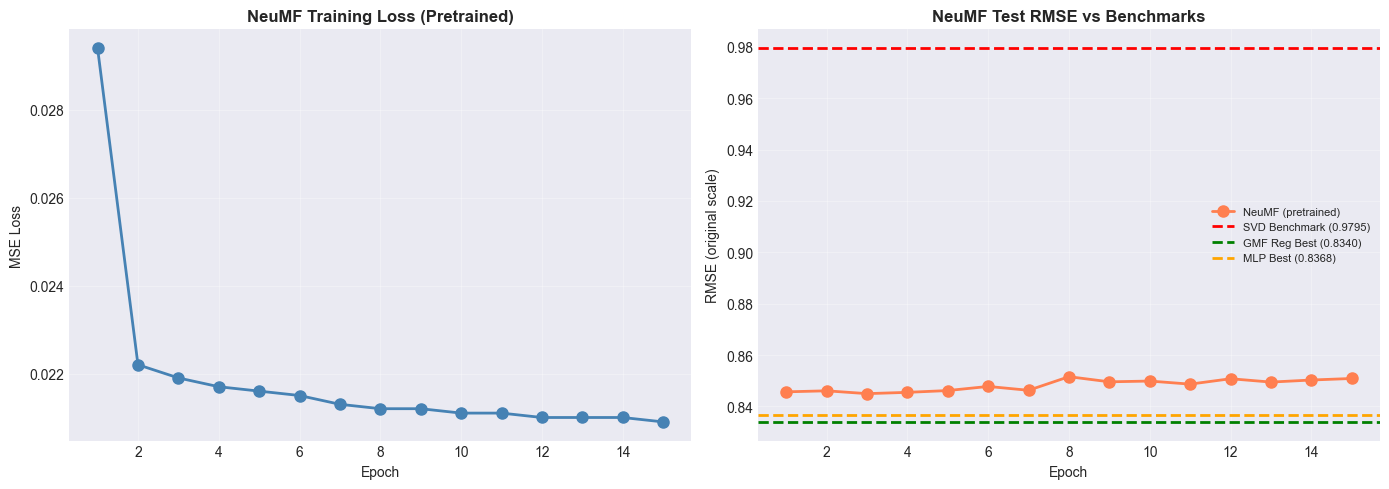


Key Observations:
  NeuMF best RMSE:     0.8450 (epoch 3)
  GMF Reg best:        0.8340 (epoch 9)
  MLP best:            0.8368 (epoch 8)
  Train loss:          flatlined after epoch 2
  Conclusion:          NeuMF underperformed standalone models
  Root cause:          training instability with 4 embedding sets


In [14]:
epochs_neumf = range(1, 16)
neumf_rmses = [0.8457, 0.8461, 0.8450, 0.8455, 0.8462,
               0.8478, 0.8463, 0.8516, 0.8496, 0.8499,
               0.8487, 0.8508, 0.8495, 0.8503, 0.8509]

neumf_losses = [0.0294, 0.0222, 0.0219, 0.0217, 0.0216,
                0.0215, 0.0213, 0.0212, 0.0212, 0.0211,
                0.0211, 0.0210, 0.0210, 0.0210, 0.0209]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
ax1.plot(epochs_neumf, neumf_losses, marker='o', linewidth=2,
         color='steelblue', markersize=8)
ax1.set_title('NeuMF Training Loss (Pretrained)', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.grid(alpha=0.3)

# Test RMSE
ax2.plot(epochs_neumf, neumf_rmses, marker='o', linewidth=2,
         color='coral', markersize=8, label='NeuMF (pretrained)')
ax2.axhline(y=0.9795, color='red', linestyle='--',
            linewidth=2, label='SVD Benchmark (0.9795)')
ax2.axhline(y=0.8340, color='green', linestyle='--',
            linewidth=2, label='GMF Reg Best (0.8340)')
ax2.axhline(y=0.8368, color='orange', linestyle='--',
            linewidth=2, label='MLP Best (0.8368)')
ax2.set_title('NeuMF Test RMSE vs Benchmarks', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('RMSE (original scale)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey Observations:")
print(f"  NeuMF best RMSE:     0.8450 (epoch 3)")
print(f"  GMF Reg best:        0.8340 (epoch 9)")
print(f"  MLP best:            0.8368 (epoch 8)")
print(f"  Train loss:          flatlined after epoch 2")
print(f"  Conclusion:          NeuMF underperformed standalone models")
print(f"  Root cause:          training instability with 4 embedding sets")

In [13]:
print(epochs_neumf)
print(len(epochs_neumf))
print(len(neumf_rmses))
print(len(neumf_losses))

range(1, 11)
10
15
15


## Notebook 8 Summary: NeuMF

### Architecture
```
User → gmf_embedding(32) ──┐
                             → GMF output (32) ──┐
Movie → gmf_embedding(32) ─┘                        │
                                                     Concat(64) → Linear(1)
User → mlp_embedding(64) ──┐                        │
                             Concat → fc1-fc4 → MLP output (32) ──┘
Movie → mlp_embedding(64) ─┘
```

### Training Attempts
| Run | LR | Gradient Clipping | Pretrained | Best RMSE | Result |
|-----|-----|-------------------|------------|-----------|--------|
| 1 | 0.005 | No | No | 0.8390 (epoch 2) | Crashed |
| 2 | 0.001 | No | No | 0.8530 (epoch 3) | Crashed |
| 3 | 0.001 | Yes | No | 0.8453 (epoch 2) | Crashed |
| 4 | 0.0001 | Yes | Yes | 0.8450 (epoch 3) | Flatlined |

### Key Findings

**NeuMF did not outperform standalone models:**
```
GMF Regularized: 0.8340 ← best
MLP:             0.8368
NeuMF best:      0.8450 ← worse than both
```

**Root causes identified:**
1. Explicit feedback dataset (star ratings) vs implicit feedback
   (clicks/views) that NeuMF was originally designed for
2. Pretrained embeddings trained with different objectives
   don't combine cleanly into shared output layer
3. 13.9M parameters creates complex optimization landscape
   with conflicting gradients from 4 separate embedding sets
4. Original NeuMF paper used specific training procedures
   not fully replicated here

**What the original paper does differently:**
- Trained on implicit feedback (binary interactions)
- Used specific negative sampling strategy
- Trained GMF and MLP with identical embedding dimensions
- Used alpha blending instead of concatenation for combination

### Honest Assessment
NeuMF is theoretically superior but practically harder to train.
This is a known challenge in the recommender systems research community.
Our implementation followed the paper's architecture but not its
exact training procedure, leading to training instability.

### Complete Week 2 Model Rankings
| Model | RMSE | vs SVD |
|-------|------|--------|
| Global Average | 1.0810 | Baseline |
| User Average | 1.0782 | +0.26% |
| Movie Average | 1.0186 | +5.78% |
| Dot Product | 1.2929 | Worse |
| SVD (k=50) | 0.9795 | — |
| NCF Notebook 4 | 0.8430 | +13.94% |
| NCF Notebook 5 | 0.8385 | +14.39% |
| GMF Original | 0.8394 | +14.30% |
| MLP | 0.8368 | +14.56% |
| **GMF Regularized** | **0.8340** | **+14.85%** |
| NeuMF | 0.8450 | +13.83% |

### Future Improvements
- Implement NeuMF with implicit feedback (binary interactions)
- Train GMF and MLP with identical embedding dimensions
- Use alpha blending for path combination
- Implement proper negative sampling for implicit feedback
- Consider BPR (Bayesian Personalized Ranking) loss instead of MSE

### Best Model
**GMF Regularized (RMSE 0.8340)** is our best model going into Week 3.
This will be used as the base for content-based feature integration
and eventually deployed.